# Regresión Lineal Múltiple

La forma funcional del modelo de regresión lineal múltiple es:

$$
E(y_{i}|x_{i1}, x_{i2}, \ldots, x_{ip}) = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \ldots + \beta_p x_{ip}
$$



## Algunos comentarios:



### - Si realizamos un reescalamiento o traslación de las $X_{i}$, los coeficientes $\beta_{i}$ se modificarán, pero los valores estimados $\hat{E}(y_{i}|x_{i1}, x_{i2}, \ldots, x_{ip})$ serán los mismos.



In [ ]:
#importamos unos datos de ejemplo
datos<-mtcars

str(datos)

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


| Variable | Tipo de dato        | Descripción                                                                                                      |
| -------- | ------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **mpg**  | Continua (numérica) | *Miles per gallon* — Millas por galón. Mide el rendimiento de combustible.                                       |
| **cyl**  | Entera (discreta)   | Número de cilindros del motor (4, 6, 8).                                                                         |
| **disp** | Continua (numérica) | *Displacement* — Desplazamiento del motor en pulgadas cúbicas. Representa el volumen total de los cilindros.     |
| **hp**   | Continua (numérica) | *Gross horsepower* — Potencia bruta del motor en caballos de fuerza.                                             |
| **drat** | Continua (numérica) | *Rear axle ratio* — Relación del eje trasero (vueltas del eje de transmisión por vuelta de las ruedas traseras). |
| **wt**   | Continua (numérica) | Peso del vehículo en miles de libras (lb × 10³).                                                                 |
| **qsec** | Continua (numérica) | Tiempo (en segundos) para recorrer ¼ de milla (*1/4 mile time*).                                                 |
| **vs**   | Binaria (0/1)       | Tipo de motor: 0 = en V, 1 = en línea (*V-shaped / Straight*).                                                   |
| **am**   | Binaria (0/1)       | Tipo de transmisión: 0 = automática, 1 = manual.                                                                 |
| **gear** | Entera (discreta)   | Número de marchas hacia adelante (3, 4 o 5).                                                                     |
| **carb** | Entera (discreta)   | Número                                                                                                           |


Ajustando el modelo con las variables asi como están:

$$
E(mpg|wt, hp) = \beta_0 + \beta_1 wt + \beta_2 hp
$$

Y el modelo estandarizando wt (denotado como $wt^{*}$)

$$
E(mpg|wt^{*}, hp) = \beta_0 + \beta_1 wt^{*} + \beta_2 hp
$$


In [7]:
# modelo con variables asi como vienen
mod1<-lm(mpg~wt+hp, data=datos)

summary(mod1)


# modelo estandarizando wt
datos$wt_s<-scale(datos$wt)

mod2<-lm(mpg~wt_s+hp, data=datos)

summary(mod2)




Call:
lm(formula = mpg ~ wt + hp, data = datos)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 37.22727    1.59879  23.285  < 2e-16 ***
wt          -3.87783    0.63273  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12



Call:
lm(formula = mpg ~ wt_s + hp, data = datos)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 24.75132    1.40164  17.659  < 2e-16 ***
wt_s        -3.79429    0.61910  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12


Vamos a comparar sus coeficientes:

`height` was translated to `width`.


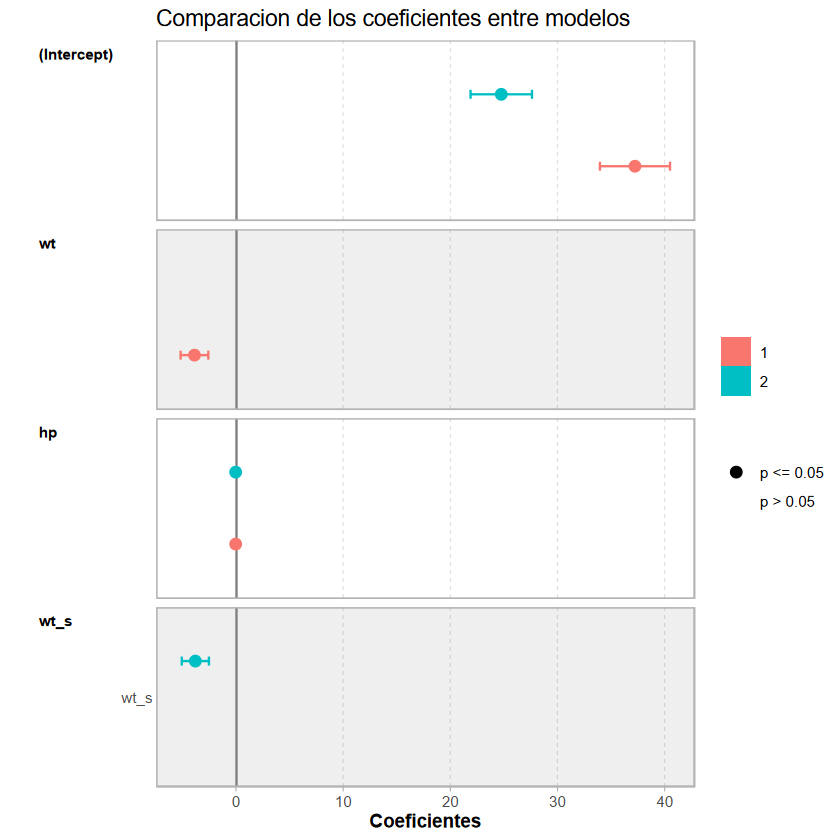

In [9]:
library(ggstats)
library(broom.helpers) # ES NECESARIA PARA ALGUNAS FUNCIONES DE ggstats

ggcoef_compare(list(mod1, mod2),intercept = TRUE) +
ggplot2::xlab("Coeficientes") +
ggplot2::ggtitle("Comparacion de los coeficientes entre modelos") +
ggplot2::theme(legend.position = "right")

Sin embargo, los valores estimados $\hat{E}(mpg|wt, hp)$ y $\hat{E}(mpg|wt^{*}, hp)$ serán los mismos para cada observación, ya que el reescalamiento de $wt$ no afecta la capacidad predictiva del modelo.

Warning message:
"package 'ggplot2' was built under R version 4.5.2"


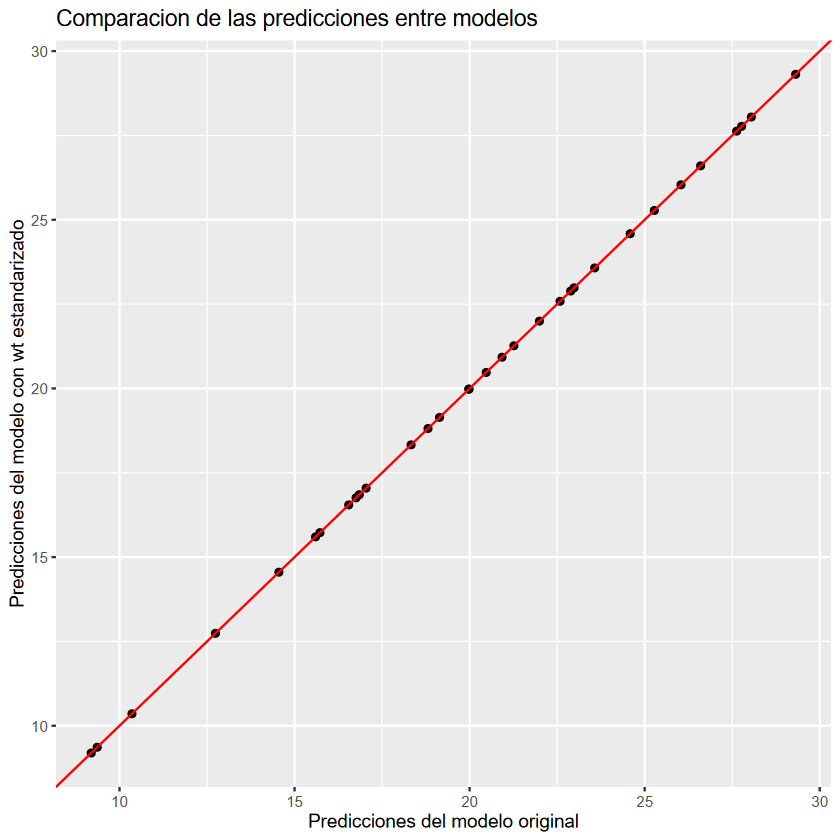

In [13]:
library(ggplot2)


pred1<-predict(mod1)
pred2<-predict(mod2)

ggplot(datos, aes(x=pred1, y=pred2)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0, color="red") +
  xlab("Predicciones del modelo original") +
  ylab("Predicciones del modelo con wt estandarizado") +
  ggtitle("Comparacion de las predicciones entre modelos") +
  theme(legend.position = "right")

### - Lo mismo ocurre si tenemos una variable categórica con más de dos categorías y cambiamos la categoría de referencia, los coeficientes se modificarán, pero los valores estimados $\hat{E}(y_{i}|x_{i1}, x_{i2}, \ldots, x_{ip})$ seguirán siendo los mismos para cada observación.

La variable gear tiene 3 categorías (3, 4 y 5). 

Ajustando el modelo con nivel de referencia en la categoría "3" (denotado como gear_{3})

$$
E(mpg|gear_{3},wt) = \beta_0 + \beta_1 I(gear_{3}=4) + \beta_2 I(gear_{3}=5) + \beta_3 wt
$$

Ajustando el modelo con nivel de referencia en la categoría "4" (denotado como gear_{4}):
$$
E(mpg|gear_{4},wt) = \beta_0 + \beta_1 I(gear_{4}=3) + \beta_2 I(gear_{4}=5) + \beta_3 wt
$$





In [11]:
# modelo con gear3

# ASI SE INDICA QUE UNA VARIABLE ES CATEGORICA, Y SE LE ASIGNAN LOS NIVELES Y ETIQUETAS CORRESPONDIENTES
datos$gear<-factor(datos$gear,levels = c(3,4,5),labels = c("gear3","gear4","gear5"))

mod3<-lm(mpg~wt+hp+gear, data=datos)

#summary(mod3)


# modelo con gear4 como referencia
datos$gear<-relevel(datos$gear, ref = "gear4") #solo actualizamos el nivel de referencia, el resto de niveles y etiquetas se mantienen igual

mod4<-lm(mpg~wt+hp+gear, data=datos)

#summary(mod4)



Comparamos sus coeficientes y sus predicciones:

`height` was translated to `width`.


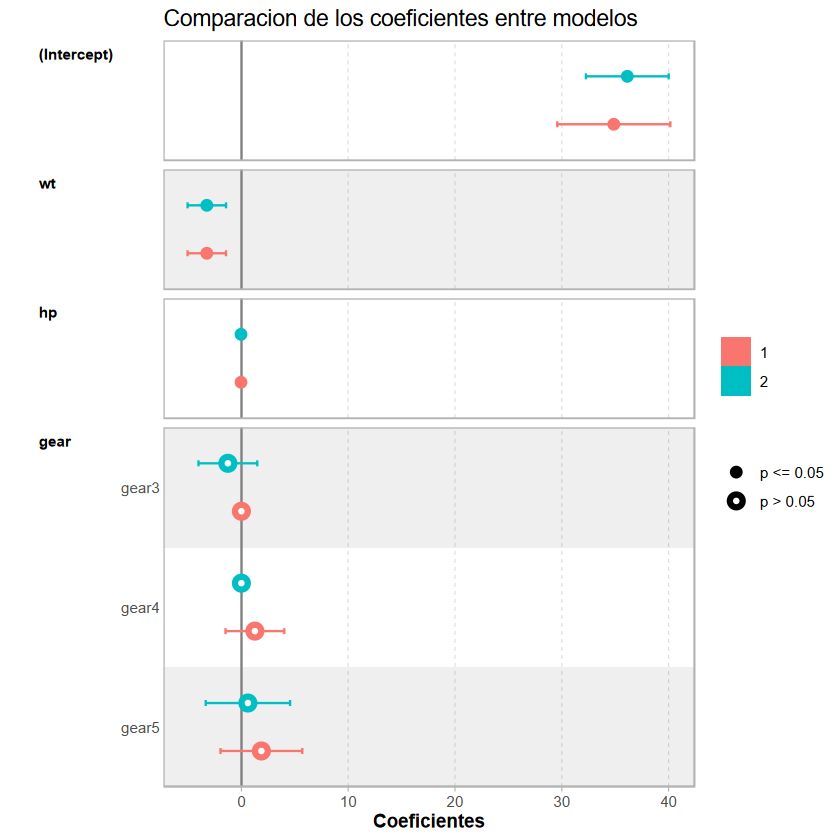

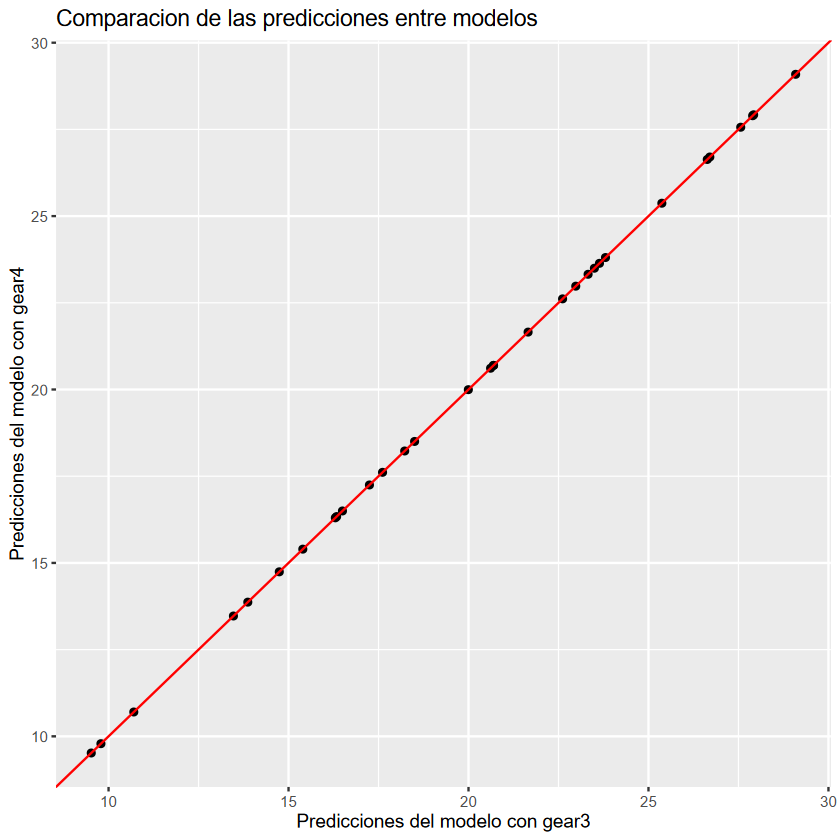

In [14]:
ggcoef_compare(list(mod3, mod4),intercept = TRUE) +
ggplot2::xlab("Coeficientes") +
ggplot2::ggtitle("Comparacion de los coeficientes entre modelos") +
ggplot2::theme(legend.position = "right")


pred3<-predict(mod3)
pred4<-predict(mod4)

ggplot(datos, aes(x=pred3, y=pred4)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0, color="red") +
  xlab("Predicciones del modelo con gear3") +
  ylab("Predicciones del modelo con gear4") +
  ggtitle("Comparacion de las predicciones entre modelos") +
  theme(legend.position = "right")

### - Interpretación de los coeficientes 


En un modelo de regresión múltiple, cada parámetro $\beta_j$ representa el **efecto promedio que tiene la variable explicativa $x_j$ sobre la variable de respuesta $y$, manteniendo constantes las demás variables del modelo.**  


$$
\mathbb{E}(y \mid x_1, x_2, \ldots, x_p) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p
$$

donde:  

- $\beta_0$ es el intercepto o término constante, que representa el valor esperado de $y$ cuando todas las variables explicativas continuas valen cero y las categóricas están en su nivel de referencia.  

- $\beta_j$ (para $j = 1, 2, \ldots, p$) mide el cambio promedio en la esperanza de $y$ ante un incremento de una unidad en $x_j$, suponiendo que todas las demás variables permanecen fijas.  

Por tanto, la interpretación de los coeficientes en la regresión múltiple es condicional: cada efecto parcial de una variable se estima después de descontar la influencia de las otras variables incluidas en el modelo.

### - Interpretación de las pruebas t 

Para el constraste individual

$$
H_0: \beta_j = 0 \quad vs \quad
H_1: \beta_j \neq 0
$$

En la regresión múltiple, la prueba t para un parámetro $\beta_j$ se interpreta de manera **condicional** y no asilada, como en la regresión simple.  

Esto significa que la hipótesis $H_0: \beta_j = 0$ se lee: **El coeficiente asociado a la j-ésima variable es cero, dado que todas las demás variables explicativas permanecen en el modelo.**  

En otras palabras:

- La prueba t analiza **si la variable $x_j$ aporta información adicional** en la explicación de $\mathbb{E}(y \mid x_1, x_2, \ldots, x_p)$, una vez que **las demás variables ya han sido consideradas**.

- Si $H_0$ no se rechaza, se interpreta que $x_j$ no contribuye significativamente a explicar la respuesta esperada de $y$, más allá del efecto de las demás variables incluidas.  

Esto significa que si hay dos variables que no rechazan $H_0$, es un error común pensar que ambas son irrelevantes y sacar ambas del modelo, pues una de ellas puede ser redundante en presencia de la otra, ya que su efecto puede estar siendo capturado por otra variable incluida en el modelo.

En la salida `summary()`, el valor del estadistico de prueba t y el pvalue asociado a la prueba $H_0: \beta_j = 0$ aparecen en la columna "t value" y "Pr(>|t|)", respectivamente. 


```{r}

Coefficients:
              t value  Pr(>|t|)    
(Intercept)   17.659   < 2e-16 ***
wt_s         -6.129    1.12e-06 ***
hp           -3.519    0.00145 ** 

```





In [18]:
summary(mod2)

summary(mod2)$coefficients


Call:
lm(formula = mpg ~ wt_s + hp, data = datos)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 24.75132    1.40164  17.659  < 2e-16 ***
wt_s        -3.79429    0.61910  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12


,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),24.75131916,1.40164248,17.658796,4.655104e-17
wt_s,-3.79429235,0.61910280,-6.128695,1.119647e-06
hp,-0.03177295,0.00902971,-3.518712,1.451229e-03


O accediendo a los elementos del objeto `summary(mod2)$coefficients`:


In [19]:
summary(mod2)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),24.75131916,1.40164248,17.658796,4.655104e-17
wt_s,-3.79429235,0.61910280,-6.128695,1.119647e-06
hp,-0.03177295,0.00902971,-3.518712,1.451229e-03


### - Primera cosa a revisar cuando se ajusta un modelo de regresión:

La prueba más importante a revisar es la prueba F global, que evalúa si al menos una de las variables explicativas ayuda a modelar $\mathbb{E}(y \mid x_1, x_2, \ldots, x_p)$.

En caso de que no se rechace la hipótesis nula de la prueba F global, no tiene sentido revisar las pruebas t individuales, pues el modelo no es significativo en su conjunto.

En la salida `summary()`, aparece al final como 


```{r}

F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12

```

In [15]:
summary(mod2)


Call:
lm(formula = mpg ~ wt_s + hp, data = datos)

Residuals:
   Min     1Q Median     3Q    Max 
-3.941 -1.600 -0.182  1.050  5.854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 24.75132    1.40164  17.659  < 2e-16 ***
wt_s        -3.79429    0.61910  -6.129 1.12e-06 ***
hp          -0.03177    0.00903  -3.519  0.00145 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.593 on 29 degrees of freedom
Multiple R-squared:  0.8268,	Adjusted R-squared:  0.8148 
F-statistic: 69.21 on 2 and 29 DF,  p-value: 9.109e-12


O accediendo a los elementos del objeto `summary(mod2)$fstatistic`:

In [25]:
summary(mod2)$fstatistic

names(summary(mod2))

value    numdf    dendf 
69.21121  2.00000 29.00000

[1] "call"          "terms"         "residuals"     "coefficients" 
 [5] "aliased"       "sigma"         "df"            "r.squared"    
 [9] "adj.r.squared" "fstatistic"    "cov.unscaled"

En general el objeto `summary(mod2)` es un vector con los siguientes elementos:

- call
- residuals
- coefficients
- sigma
- df
- r.squared
- adj.r.squared
- fstatistic


### - Pruebas de hipótesis avanzadas

Podemos clasificar las pruebas de hipótesis en regresión múltiple en:

- Individuales (una sola condición): 
    - Pruebas t para cada parámetro $\beta_j = 0 $. (Se interpretan de forma condicional, dado que las demás variables permanecen en el modelo).
    - Pruebas sobre una combinación lineal de parámetros $\alpha_0 \beta_0 + \alpha_1 \beta_1 + \alpha_2 \beta_2 + \ldots + \alpha_p \beta_p = c$.

- Conjuntas (varias condiciones simultáneas):
    - Prueba F para todas las variables del modelo: $H_0: \beta_1 = \beta_2 = \ldots = \beta_p = 0$.
    - Prueba F para un subconjunto de variables: $H_0: \beta_{j_1} = \beta_{j_2} = \ldots = \beta_{j_k} = 0$, donde $j_1, j_2, \ldots, j_k$ es un subconjunto de $\{1, 2, \ldots, p\}$.

    - Prueba lineal general (r condiciones sobre combinaciones lineales): $H_0: RB = r$

La prueba lineal general es engloba a todas las pruebas anteriores, pues cada una de ellas se puede expresar como una prueba lineal general con diferentes matrices $R$ y $r$.

Para implementar esta prueba en R, se puede usar la función `glht()` del paquete `multcomp`, que permite especificar las hipótesis a través de las matrices $R$ y $r$.

Supongamos que tenemos el modelo:

$$
E(y|x_1, x_2, x_3) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3
$$

Y queremos probar la hipótesis:

$$
H_0: \begin{cases}
\beta_1 = - \beta_2 \\
\beta_3 = 2 \beta_1 + 0.5 
\end{cases}
\quad vs \quad
H_1: \text{al menos una de las condiciones anteriores no se cumple}
$$


En este caso, la matriz $R$ y el vector $r$ serían:

$$
R = \begin{bmatrix}
0 & 1 & 1 & 0 \\
0 & -2 & 0 & 1
\end{bmatrix}, \quad r = \begin{bmatrix}
0 \\
0.5
\end{bmatrix}
$$

In [27]:
library(multcomp)

# Orden de coeficientes:
# (Intercepto), wt, hp, qsec, drat


mod_ph <- lm(mpg ~ wt + hp +qsec , data = datos)


# Matriz de restricciones
K <- rbind(
    c(0, 1, 1, 0),     #  beta1 + beta2 = 0
    c(0, -2, 0, 1)     #  -2*beta1 + beta3 = 0.5
)


# Vector de valores bajo la hipótesis nula
r<- c(0, 0.5)

# Prueba simultánea
test <- glht(mod_ph, linfct = K, rhs = r)


# resumen
summary(test)


	 Simultaneous Tests for General Linear Hypotheses

Fit: lm(formula = mpg ~ wt + hp + qsec, data = datos)

Linear Hypotheses:
         Estimate Std. Error t value Pr(>|t|)    
1 == 0    -4.3766     0.7412  -5.905 3.18e-06 ***
2 == 0.5   9.2284     1.7849   4.890 4.93e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
(Adjusted p values reported -- single-step method)
